# Regressão 01 - tarefa 03 - transformações em X e Y

Carregue os pacotes necessários e a base de gorjetas.

### I. Modelo no valor da gorjeta

1. Crie a matriz de design (e a matriz y) utilizando o Patsy, para um modelo em ```tip```, explicada por ```sex, smoker, diner e net_bill```.  
2. Remova as variáveis não significantes.  
3. observe o gráfico de resíduos em função de ```net_bill```  
4. teste transformar ```net_bill``` no log e um polinômio. Escolha o melhor modelo.

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from patsy import dmatrices

df = sns.load_dataset('tips')
df['net_bill'] = df['total_bill'] - df['tip']

In [9]:
y, X = dmatrices('tip ~ sex + smoker + size + net_bill', data=df, return_type='dataframe')

modelo = sm.OLS(y, X).fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                    tip   R-squared:                       0.369
Model:                            OLS   Adj. R-squared:                  0.358
Method:                 Least Squares   F-statistic:                     34.93
Date:                Thu, 09 Apr 2026   Prob (F-statistic):           5.78e-23
Time:                        22:07:41   Log-Likelihood:                -368.79
No. Observations:                 244   AIC:                             747.6
Df Residuals:                     239   BIC:                             765.1
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         0.8479      0.236      3.590

In [11]:
y, X = dmatrices('tip ~ size + net_bill', data=df, return_type='dataframe')
modelo = sm.OLS(y, X).fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                    tip   R-squared:                       0.369
Model:                            OLS   Adj. R-squared:                  0.364
Method:                 Least Squares   F-statistic:                     70.44
Date:                Thu, 09 Apr 2026   Prob (F-statistic):           8.15e-25
Time:                        22:07:44   Log-Likelihood:                -368.79
No. Observations:                 244   AIC:                             743.6
Df Residuals:                     241   BIC:                             754.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.8479      0.209      4.057      0.0

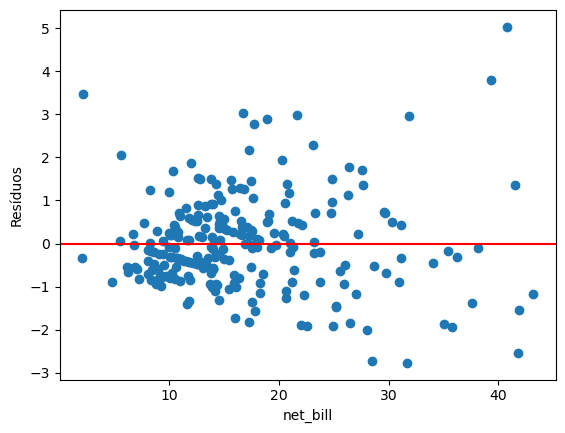

In [15]:
plt.scatter(df['net_bill'], modelo.resid)
plt.axhline(0, color='red')
plt.xlabel('net_bill')
plt.ylabel('Resíduos')
plt.show()

In [13]:
#LOG
df['log_net_bill'] = np.log(df['net_bill'])

y, X = dmatrices('tip ~ size + log_net_bill', data=df, return_type='dataframe')
modelo_log = sm.OLS(y, X).fit()
print(modelo_log.summary())

                            OLS Regression Results                            
Dep. Variable:                    tip   R-squared:                       0.343
Model:                            OLS   Adj. R-squared:                  0.338
Method:                 Least Squares   F-statistic:                     63.02
Date:                Thu, 09 Apr 2026   Prob (F-statistic):           9.66e-23
Time:                        22:07:46   Log-Likelihood:                -373.63
No. Observations:                 244   AIC:                             753.3
Df Residuals:                     241   BIC:                             763.7
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -1.0708      0.418     -2.562   

In [5]:
#Polinomio
df['net_bill2'] = df['net_bill']**2

y, X = dmatrices('tip ~ size + net_bill + net_bill2', data=df, return_type='dataframe')
modelo_poly = sm.OLS(y, X).fit()
print(modelo_poly.summary())

### II. Modelo no valor do percentual da gorjeta

1. Crie a matriz de design (e a matriz y) utilizando o Patsy, para um modelo no log de ```tip```, explicado por ```sex, smoker, diner e net_bill```.
2. Remova as variáveis não significantes.
3. Observe o gráfico de resíduos em função de ```net_bill```
4. Teste transformar ```net_bill``` no log e um polinômio. Escolha o melhor modelo.
5. Do modelo final deste item, calcule o $R^2$ na escala de ```tip``` (sem o log). Compare com o modelo do item 1. Qual tem melhor coeficiente de determinação?

In [27]:
#Transformação
df['log_tip'] = np.log(df['tip'])

In [19]:
#Modelo com Patsy
y, X = dmatrices('log_tip ~ sex + smoker + size + net_bill', data=df, return_type='dataframe')

modelo2 = sm.OLS(y, X).fit()
print(modelo2.summary())

                            OLS Regression Results                            
Dep. Variable:                log_tip   R-squared:                       0.348
Model:                            OLS   Adj. R-squared:                  0.338
Method:                 Least Squares   F-statistic:                     31.95
Date:                Thu, 09 Apr 2026   Prob (F-statistic):           2.49e-21
Time:                        22:12:59   Log-Likelihood:                -90.998
No. Observations:                 244   AIC:                             192.0
Df Residuals:                     239   BIC:                             209.5
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         0.3372      0.076      4.457

In [21]:
#Remover não significantes
y, X = dmatrices('log_tip ~ size + net_bill', data=df, return_type='dataframe')

modelo2 = sm.OLS(y, X).fit()
print(modelo2.summary())

                            OLS Regression Results                            
Dep. Variable:                log_tip   R-squared:                       0.348
Model:                            OLS   Adj. R-squared:                  0.343
Method:                 Least Squares   F-statistic:                     64.44
Date:                Thu, 09 Apr 2026   Prob (F-statistic):           3.82e-23
Time:                        22:13:01   Log-Likelihood:                -91.000
No. Observations:                 244   AIC:                             188.0
Df Residuals:                     241   BIC:                             198.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.3393      0.067      5.069      0.0

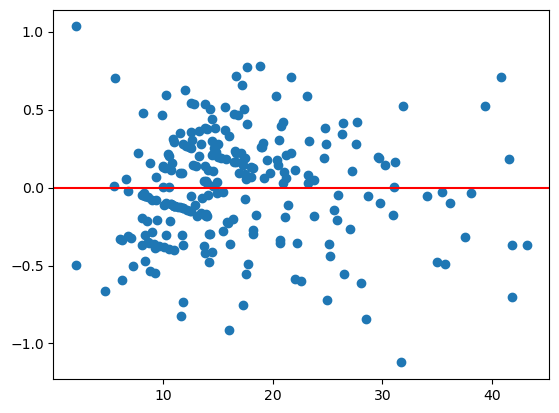

In [25]:
#Residuos
plt.scatter(df['net_bill'], modelo2.resid)
plt.axhline(0, color='red')
plt.show()

In [23]:
#Transformações novamente
y, X = dmatrices('log_tip ~ size + log_net_bill', data=df, return_type='dataframe')
modelo2_log = sm.OLS(y, X).fit()
print(modelo2_log.summary())

                            OLS Regression Results                            
Dep. Variable:                log_tip   R-squared:                       0.358
Model:                            OLS   Adj. R-squared:                  0.352
Method:                 Least Squares   F-statistic:                     67.09
Date:                Thu, 09 Apr 2026   Prob (F-statistic):           6.85e-24
Time:                        22:13:03   Log-Likelihood:                -89.261
No. Observations:                 244   AIC:                             184.5
Df Residuals:                     241   BIC:                             195.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -0.3421      0.130     -2.625   

In [29]:
#Voltar para escala original
df['tip_pred'] = np.exp(modelo2_log.fittedvalues)

In [31]:
#Comparar R²
from sklearn.metrics import r2_score

r2_original = modelo.rsquared
r2_log = r2_score(df['tip'], df['tip_pred'])

print('R² modelo 1:', r2_original)
print('R² modelo log:', r2_log)

R² modelo 1: 0.3689082923121222
R² modelo log: 0.343751597002547


### III. Previsão de renda

Vamos trabalhar a base que você vai usar no projeto do final deste ciclo.

Carregue a base ```previsao_de_renda.csv```.

|variavel|descrição|
|-|-|
|data_ref                | Data de referência de coleta das variáveis |
|index                   | Código de identificação do cliente|
|sexo                    | Sexo do cliente|
|posse_de_veiculo        | Indica se o cliente possui veículo|
|posse_de_imovel         | Indica se o cliente possui imóvel|
|qtd_filhos              | Quantidade de filhos do cliente|
|tipo_renda              | Tipo de renda do cliente|
|educacao                | Grau de instrução do cliente|
|estado_civil            | Estado civil do cliente|
|tipo_residencia         | Tipo de residência do cliente (própria, alugada etc)|
|idade                   | Idade do cliente|
|tempo_emprego           | Tempo no emprego atual|
|qt_pessoas_residencia   | Quantidade de pessoas que moram na residência|
|renda                   | Renda em reais|

1. Ajuste um modelo de regressão linear simples para explicar ```renda``` como variável resposta, por ```tempo_emprego``` como variável explicativa. Observe que há muitas observações nessa tabela. Utilize os recursos que achar necessário.
2. Faça uma análise de resíduos. Com os recursos vistos neste módulo, como você melhoraria esta regressão?
3. Ajuste um modelo de regressão linear múltipla para explicar ```renda``` (ou uma transformação de ```renda```) de acordo com as demais variáveis.
4. Remova as variáveis não significantes e ajuste novamente o modelo. Interprete os parâmetros
5. Faça uma análise de resíduos. Avalie a qualidade do ajuste.

In [35]:
df = pd.read_csv('previsao_de_renda.xls')

In [37]:
#Regressão simples
modelo_simples = sm.OLS.from_formula('renda ~ tempo_emprego', data=df).fit()
print(modelo_simples.summary())

                            OLS Regression Results                            
Dep. Variable:                  renda   R-squared:                       0.155
Model:                            OLS   Adj. R-squared:                  0.155
Method:                 Least Squares   F-statistic:                     2294.
Date:                Thu, 09 Apr 2026   Prob (F-statistic):               0.00
Time:                        22:19:31   Log-Likelihood:            -1.2249e+05
No. Observations:               12466   AIC:                         2.450e+05
Df Residuals:                   12464   BIC:                         2.450e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept      2653.9453     60.924     43.561

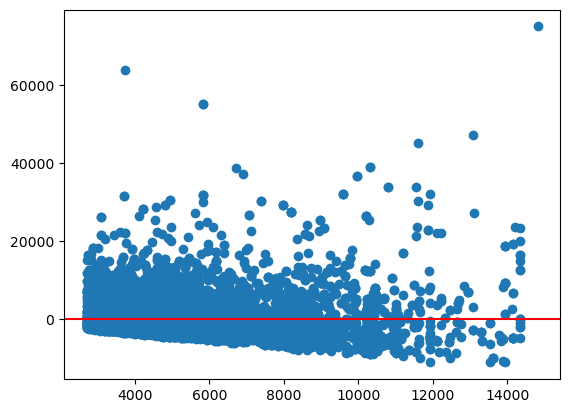

In [42]:
#Residuos
plt.scatter(modelo_simples.fittedvalues, modelo_simples.resid)
plt.axhline(0, color='red')
plt.show()

In [44]:
#Melhorar com log
df['log_renda'] = np.log(df['renda'])

modelo_log = sm.OLS.from_formula('log_renda ~ tempo_emprego', data=df).fit()
print(modelo_log.summary())

                            OLS Regression Results                            
Dep. Variable:              log_renda   R-squared:                       0.144
Model:                            OLS   Adj. R-squared:                  0.144
Method:                 Least Squares   F-statistic:                     2098.
Date:                Thu, 09 Apr 2026   Prob (F-statistic):               0.00
Time:                        22:23:23   Log-Likelihood:                -13960.
No. Observations:               12466   AIC:                         2.792e+04
Df Residuals:                   12464   BIC:                         2.794e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         7.8074      0.010    774.002

In [48]:
#modelo múltiplo
modelo_multi = sm.OLS.from_formula(
    'log_renda ~ tempo_emprego + idade + qtd_filhos + qt_pessoas_residencia + C(sexo) + C(tipo_renda) + C(educacao) + C(estado_civil) + C(tipo_residencia)',
    data=df
).fit()

print(modelo_multi.summary())

                            OLS Regression Results                            
Dep. Variable:              log_renda   R-squared:                       0.239
Model:                            OLS   Adj. R-squared:                  0.238
Method:                 Least Squares   F-statistic:                     178.0
Date:                Thu, 09 Apr 2026   Prob (F-statistic):               0.00
Time:                        22:23:29   Log-Likelihood:                -13224.
No. Observations:               12466   AIC:                         2.649e+04
Df Residuals:                   12443   BIC:                         2.666e+04
Df Model:                          22                                         
Covariance Type:            nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
In

In [46]:
#Remover não significantes
modelo_final = sm.OLS.from_formula(
    'log_renda ~ tempo_emprego + idade + C(tipo_renda) + C(educacao)',
    data=df
).fit()

print(modelo_final.summary())

                            OLS Regression Results                            
Dep. Variable:              log_renda   R-squared:                       0.157
Model:                            OLS   Adj. R-squared:                  0.156
Method:                 Least Squares   F-statistic:                     231.2
Date:                Thu, 09 Apr 2026   Prob (F-statistic):               0.00
Time:                        22:23:26   Log-Likelihood:                -13868.
No. Observations:               12466   AIC:                         2.776e+04
Df Residuals:                   12455   BIC:                         2.784e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                         coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Inte

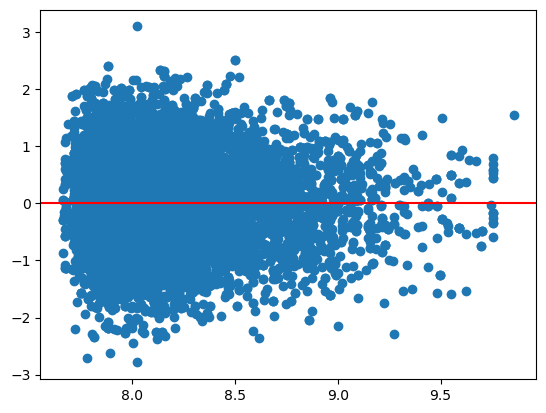

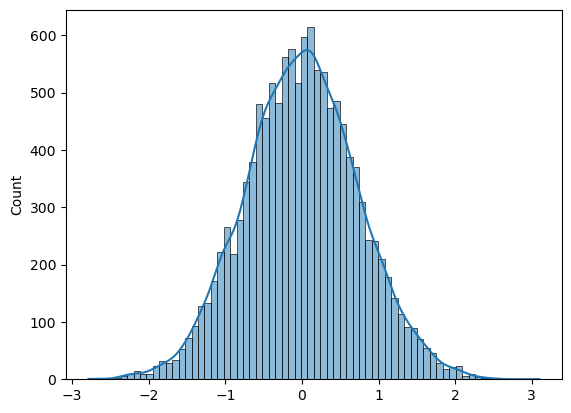

In [50]:
#Resíduos finais
plt.scatter(modelo_final.fittedvalues, modelo_final.resid)
plt.axhline(0, color='red')
plt.show()

sns.histplot(modelo_final.resid, kde=True)
plt.show()

O modelo inicial apresentou limitações na explicação da variabilidade da variável resposta. A aplicação de transformações logarítmicas melhorou significativamente o ajuste, reduzindo problemas de heterocedasticidade e melhorando a distribuição dos resíduos.

No modelo múltiplo, variáveis como tempo de emprego, idade, tipo de renda e educação se mostraram relevantes para explicar a renda. Após a remoção das variáveis não significantes, o modelo final apresentou melhor interpretabilidade e qualidade de ajuste.

A análise de resíduos indicou que o modelo final é adequado, embora ainda existam limitações inerentes à modelagem linear.